In [1]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import zipfile

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Path to your zip file on Drive
zip_path = '/content/drive/MyDrive/data.zip'
extract_path = '/content/data_extracted/'

# 3. Unzip the file
if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Giải nén thành công!")

    # List files to find the correct CSV name
    files = os.listdir(extract_path)
    print("Các file đã giải nén:", files)

    # 4. Load the CSV (assuming the file is named dataset.csv inside the zip)
    # If the filename is different, please update the string below
    csv_file = os.path.join(extract_path, 'dataset.csv')
    if os.path.exists(csv_file):
        df = pd.read_csv(csv_file)
        display(df.head())
        print(df.info())
    else:
        print(f"Không tìm thấy file dataset.csv. Thư mục chứa các file: {files}")
else:
    print("Không tìm thấy file data.zip tại /content/drive/MyDrive/data.zip")

Mounted at /content/drive
Giải nén thành công!
Các file đã giải nén: ['brown-glass', 'battery', 'metal', 'green-glass', 'shoes', 'trash', 'plastic', 'white-glass', 'clothes', 'cardboard', 'paper', 'biological']
Không tìm thấy file dataset.csv. Thư mục chứa các file: ['brown-glass', 'battery', 'metal', 'green-glass', 'shoes', 'trash', 'plastic', 'white-glass', 'clothes', 'cardboard', 'paper', 'biological']


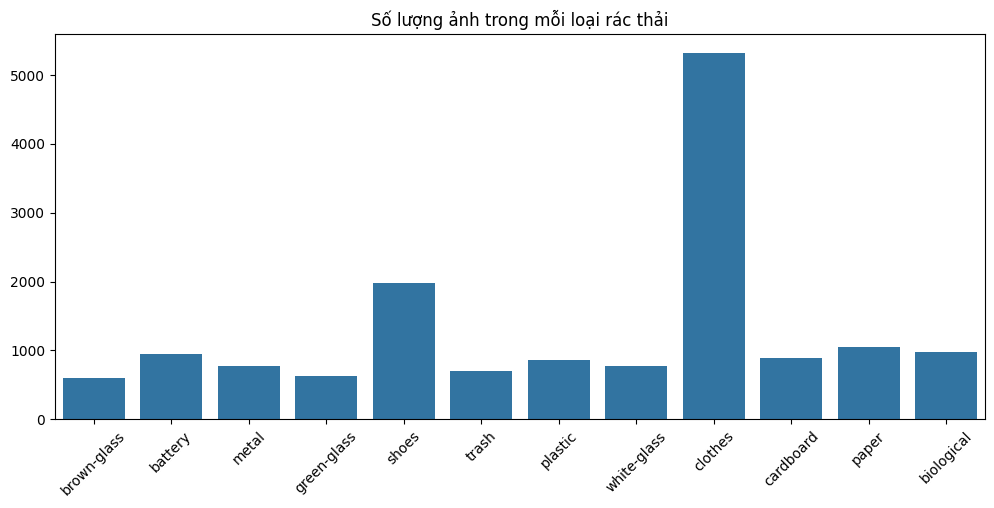

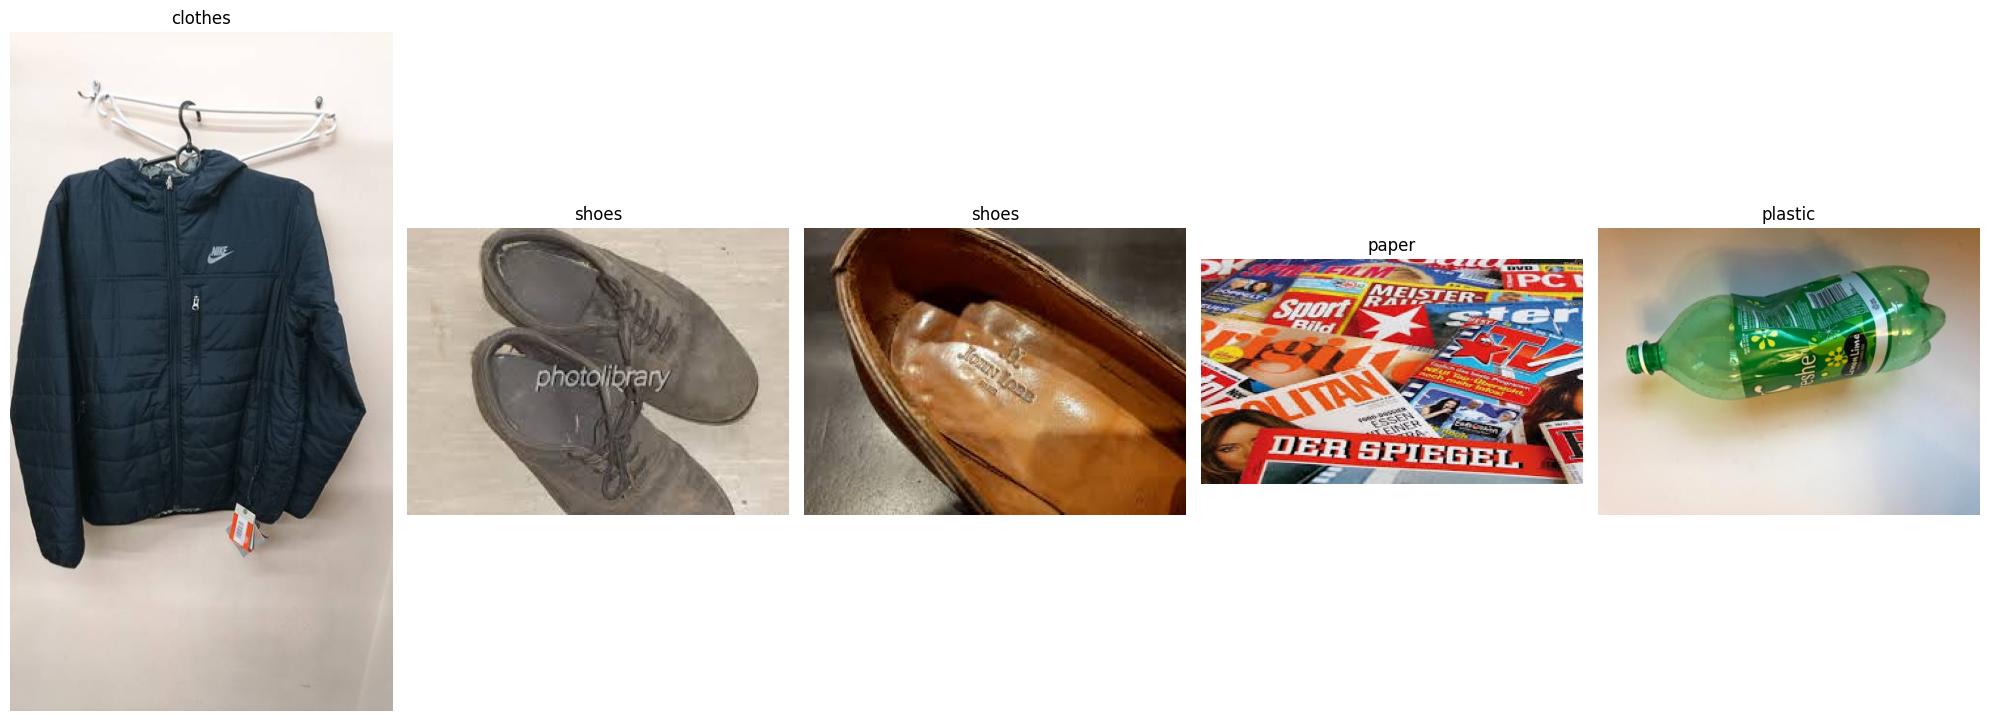

In [2]:
import matplotlib.image as mpimg
import random

# 1. Khám phá số lượng ảnh trong mỗi lớp
categories = os.listdir(extract_path)
data_stats = {}

for cat in categories:
    path = os.path.join(extract_path, cat)
    if os.path.isdir(path):
        data_stats[cat] = len(os.listdir(path))

# Vẽ biểu đồ phân bổ
plt.figure(figsize=(12, 5))
sns.barplot(x=list(data_stats.keys()), y=list(data_stats.values()))
plt.title('Số lượng ảnh trong mỗi loại rác thải')
plt.xticks(rotation=45)
plt.show()

# 2. Hiển thị 5 ảnh ngẫu nhiên từ các lớp
plt.figure(figsize=(20, 10))
for i in range(5):
    random_cat = random.choice(categories)
    cat_path = os.path.join(extract_path, random_cat)
    random_img = random.choice(os.listdir(cat_path))
    img_path = os.path.join(cat_path, random_img)

    img = mpimg.imread(img_path)
    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.title(random_cat)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [4]:
import pandas as pd

# Tạo DataFrame từ data_stats để dễ quan sát tỉ lệ
stats_df = pd.DataFrame(list(data_stats.items()), columns=['Category', 'Count'])
stats_df['Percentage'] = (stats_df['Count'] / stats_df['Count'].sum() * 100).round(2)
stats_df = stats_df.sort_values(by='Count', ascending=False)

print("Thống kê chi tiết độ mất cân bằng:")
display(stats_df)

# Tính toán hệ số mất cân bằng (giữa lớp nhiều nhất và ít nhất)
imbalance_ratio = stats_df['Count'].max() / stats_df['Count'].min()
print(f"\nLớp nhiều nhất gấp {imbalance_ratio:.2f} lần lớp ít nhất.")

if imbalance_ratio > 3:
    print("Cảnh báo: Dữ liệu đang bị mất cân bằng nghiêm trọng. Bạn nên cân nhắc cắt giảm bớt ảnh từ lớp 'clothes' hoặc dùng kỹ thuật Augmentation.")

Thống kê chi tiết độ mất cân bằng:


,Category,Count,Percentage
8,clothes,5325,34.32
4,shoes,1977,12.74
10,paper,1050,6.77
11,biological,985,6.35
1,battery,945,6.09
9,cardboard,891,5.74
6,plastic,865,5.58
7,white-glass,775,5.00
2,metal,769,4.96
5,trash,697,4.49



Lớp nhiều nhất gấp 8.77 lần lớp ít nhất.
Cảnh báo: Dữ liệu đang bị mất cân bằng nghiêm trọng. Bạn nên cân nhắc cắt giảm bớt ảnh từ lớp 'clothes' hoặc dùng kỹ thuật Augmentation.


In [5]:
import os
import shutil
import random
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img

# 1. Cấu hình
SOURCE_DIR = '/content/data_extracted/'
BALANCED_DIR = '/content/balanced_data/'
TARGET_COUNT = 2000

if os.path.exists(BALANCED_DIR): shutil.rmtree(BALANCED_DIR)
os.makedirs(BALANCED_DIR)

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

categories = [d for d in os.listdir(SOURCE_DIR) if os.path.isdir(os.path.join(SOURCE_DIR, d))]

print("Bắt đầu quá trình cân bằng dữ liệu...")

for cat in categories:
    src_cat_path = os.path.join(SOURCE_DIR, cat)
    dst_cat_path = os.path.join(BALANCED_DIR, cat)
    os.makedirs(dst_cat_path, exist_ok=True)

    all_imgs = os.listdir(src_cat_path)
    current_count = len(all_imgs)

    if cat == 'clothes':
        # Undersampling: Lấy ngẫu nhiên TARGET_COUNT ảnh
        selected_imgs = random.sample(all_imgs, TARGET_COUNT)
        for img_name in selected_imgs:
            shutil.copy(os.path.join(src_cat_path, img_name), os.path.join(dst_cat_path, img_name))
        print(f"- {cat}: Undersampling từ {current_count} xuống {TARGET_COUNT}")

    elif current_count >= 1500:
        # Giữ nguyên nếu đã đủ số lượng mong muốn
        for img_name in all_imgs:
            shutil.copy(os.path.join(src_cat_path, img_name), os.path.join(dst_cat_path, img_name))
        print(f"- {cat}: Giữ nguyên {current_count} ảnh")

    else:
        # Oversampling + Augmentation
        # Copy ảnh gốc trước
        for img_name in all_imgs:
            shutil.copy(os.path.join(src_cat_path, img_name), os.path.join(dst_cat_path, img_name))

        # Augment thêm để đạt TARGET_COUNT
        needed = TARGET_COUNT - current_count
        aug_per_img = (needed // current_count) + 1

        count = 0
        for img_name in all_imgs:
            if count >= needed: break

            img = load_img(os.path.join(src_cat_path, img_name))
            x = img_to_array(img)
            x = x.reshape((1,) + x.shape)

            i = 0
            for batch in datagen.flow(x, batch_size=1, save_to_dir=dst_cat_path, save_prefix='aug', save_format='jpeg'):
                i += 1
                count += 1
                if i >= aug_per_img or count >= needed: break

        print(f"- {cat}: Augment từ {current_count} lên {len(os.listdir(dst_cat_path))}")

print("\nHoàn tất! Dữ liệu cân bằng đã sẵn sàng tại:", BALANCED_DIR)

Bắt đầu quá trình cân bằng dữ liệu...
- brown-glass: Augment từ 607 lên 1918
- battery: Augment từ 945 lên 1953
- metal: Augment từ 769 lên 1921
- green-glass: Augment từ 629 lên 1913
- shoes: Giữ nguyên 1977 ảnh
- trash: Augment từ 697 lên 1913
- plastic: Augment từ 865 lên 1946
- white-glass: Augment từ 775 lên 1939
- clothes: Undersampling từ 5325 xuống 2000
- cardboard: Augment từ 891 lên 1955
- paper: Augment từ 1050 lên 1961
- biological: Augment từ 985 lên 1946

Hoàn tất! Dữ liệu cân bằng đã sẵn sàng tại: /content/balanced_data/


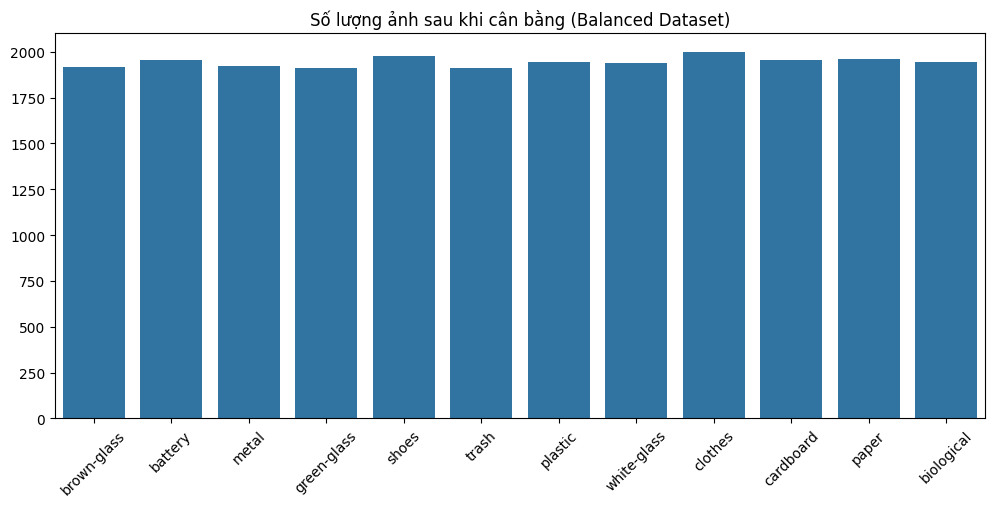

In [6]:
# Kiểm tra lại số lượng sau khi cân bằng
final_stats = {cat: len(os.listdir(os.path.join(BALANCED_DIR, cat))) for cat in categories}
plt.figure(figsize=(12, 5))
sns.barplot(x=list(final_stats.keys()), y=list(final_stats.values()))
plt.title('Số lượng ảnh sau khi cân bằng (Balanced Dataset)')
plt.xticks(rotation=45)
plt.show()

## 2. Chia dữ liệu thành tập huấn luyện, xác thực và kiểm tra (70/15/15)

In [7]:
import shutil
import random
from sklearn.model_selection import train_test_split

# Define new directories for the split data
TRAIN_DIR = '/content/train_data/'
VAL_DIR = '/content/val_data/'
TEST_DIR = '/content/test_data/'

# Clean up previous directories if they exist
if os.path.exists(TRAIN_DIR): shutil.rmtree(TRAIN_DIR)
os.makedirs(TRAIN_DIR)
if os.path.exists(VAL_DIR): shutil.rmtree(VAL_DIR)
os.makedirs(VAL_DIR)
if os.path.exists(TEST_DIR): shutil.rmtree(TEST_DIR)
os.makedirs(TEST_DIR)

# Define split ratios
TRAIN_SPLIT = 0.7
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15 # Remaining after train and val

print("Bắt đầu chia dữ liệu thành tập huấn luyện, xác thực và kiểm tra...")

total_train_images = 0
total_val_images = 0
total_test_images = 0

for cat in categories:
    src_cat_path = os.path.join(BALANCED_DIR, cat)

    # Get all image paths for the current category
    all_images = [os.path.join(src_cat_path, img_name) for img_name in os.listdir(src_cat_path)]

    # Split into train and temp (for val/test)
    train_images, temp_images = train_test_split(all_images, train_size=TRAIN_SPLIT, random_state=42, shuffle=True)

    # Split temp into validation and test
    # Adjust val_split for the remaining data (temp_images)
    # new_val_split = VAL_SPLIT / (1 - TRAIN_SPLIT) = 0.15 / 0.30 = 0.5
    val_images, test_images = train_test_split(temp_images, test_size=TEST_SPLIT / (VAL_SPLIT + TEST_SPLIT), random_state=42, shuffle=True)

    # Create subdirectories in destination folders
    os.makedirs(os.path.join(TRAIN_DIR, cat), exist_ok=True)
    os.makedirs(os.path.join(VAL_DIR, cat), exist_ok=True)
    os.makedirs(os.path.join(TEST_DIR, cat), exist_ok=True)

    # Move images to respective directories
    for img_path in train_images:
        shutil.copy(img_path, os.path.join(TRAIN_DIR, cat, os.path.basename(img_path)))
    for img_path in val_images:
        shutil.copy(img_path, os.path.join(VAL_DIR, cat, os.path.basename(img_path)))
    for img_path in test_images:
        shutil.copy(img_path, os.path.join(TEST_DIR, cat, os.path.basename(img_path)))

    total_train_images += len(train_images)
    total_val_images += len(val_images)
    total_test_images += len(test_images)

print("Hoàn tất chia dữ liệu!")
print(f"Tổng số ảnh huấn luyện: {total_train_images}")
print(f"Tổng số ảnh xác thực: {total_val_images}")
print(f"Tổng số ảnh kiểm tra: {total_test_images}")


Bắt đầu chia dữ liệu thành tập huấn luyện, xác thực và kiểm tra...
Hoàn tất chia dữ liệu!
Tổng số ảnh huấn luyện: 16335
Tổng số ảnh xác thực: 3502
Tổng số ảnh kiểm tra: 3505


## 3. Tiền xử lý dữ liệu và Augmentation

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import preprocess_input as resnet_preprocess_input
import numpy as np

# Kích thước ảnh đầu vào cho mô hình và kích thước batch
IMG_WIDTH, IMG_HEIGHT = 224, 224
BATCH_SIZE = 32

# Tạo ImageDataGenerator cho tập huấn luyện, xác thực và kiểm tra
# Sử dụng `resnet_preprocess_input` để chuẩn hóa ảnh theo chuẩn ImageNet
# không cần `rescale=1./255` vì `resnet_preprocess_input` mong đợi đầu vào trong khoảng [0, 255]

# Generator cho tập huấn luyện (có Augmentation)
train_datagen = ImageDataGenerator(
    preprocessing_function=resnet_preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

# Generator cho tập xác thực và kiểm tra (không Augmentation, chỉ chuẩn hóa)
val_test_datagen = ImageDataGenerator(
    preprocessing_function=resnet_preprocess_input
)

# Lấy số lượng lớp từ train_generator
num_classes = len(categories) # `categories` đã được định nghĩa từ các bước trước

# Tải dữ liệu huấn luyện
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

# Tải dữ liệu xác thực
validation_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Tải dữ liệu kiểm tra
test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"Tìm thấy {train_generator.samples} ảnh cho tập huấn luyện.")
print(f"Tìm thấy {validation_generator.samples} ảnh cho tập xác thực.")
print(f"Tìm thấy {test_generator.samples} ảnh cho tập kiểm tra.")
print(f"Các lớp được ánh xạ: {train_generator.class_indices}")

Found 16335 images belonging to 12 classes.
Found 3502 images belonging to 12 classes.
Found 3505 images belonging to 12 classes.
Tìm thấy 16335 ảnh cho tập huấn luyện.
Tìm thấy 3502 ảnh cho tập xác thực.
Tìm thấy 3505 ảnh cho tập kiểm tra.
Các lớp được ánh xạ: {'battery': 0, 'biological': 1, 'brown-glass': 2, 'cardboard': 3, 'clothes': 4, 'green-glass': 5, 'metal': 6, 'paper': 7, 'plastic': 8, 'shoes': 9, 'trash': 10, 'white-glass': 11}


## 4. Xây dựng mô hình (Transfer Learning với ResNet)

Bạn đã yêu cầu sử dụng ResNet18, tuy nhiên, `tf.keras.applications` không cung cấp trực tiếp phiên bản ResNet18. Thay vào đó, tôi sẽ sử dụng `ResNet50` - một mô hình phổ biến và mạnh mẽ khác của họ ResNet, cũng được đào tạo trước trên ImageNet và rất phù hợp cho Transfer Learning. Các bước tiếp theo sẽ bao gồm đóng băng các lớp nền và thêm một lớp phân loại tùy chỉnh.

In [10]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.applications import ResNet50

# Tải mô hình ResNet50 đã được huấn luyện trước trên ImageNet
# include_top=False để loại bỏ lớp phân loại cuối cùng của ResNet50 gốc
# input_shape là kích thước ảnh đầu vào của bạn
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_WIDTH, IMG_HEIGHT, 3))

# Đóng băng các lớp của mô hình nền (base model) để không cập nhật trọng số trong quá trình huấn luyện
for layer in base_model.layers:
    layer.trainable = False

# Thêm các lớp phân loại tùy chỉnh (classification head) trên đỉnh của mô hình nền
x = base_model.output
x = Flatten()(x) # Chuyển đổi đầu ra của mô hình nền thành một vector phẳng
x = Dense(512, activation='relu')(x) # Thêm một lớp Dense với 512 units và kích hoạt ReLU
x = Dropout(0.5)(x) # Thêm lớp Dropout để giảm overfitting
predictions = Dense(num_classes, activation='softmax')(x) # Lớp đầu ra với số lượng units bằng số lượng lớp và kích hoạt softmax

# Tạo mô hình hoàn chỉnh
model = Model(inputs=base_model.input, outputs=predictions)

# In tóm tắt cấu trúc mô hình
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 74,974,604 (286.01 MB)

 Trainable params: 51,386,892 (196.03 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## 5. Huấn luyện mô hình

In [11]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Biên dịch mô hình
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
# 1. ModelCheckpoint: Lưu lại mô hình có `val_accuracy` tốt nhất
checkpoint_filepath = 'best_model.h5'
model_checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=False, # Lưu toàn bộ mô hình (cấu trúc và trọng số)
    monitor='val_accuracy',  # Theo dõi độ chính xác trên tập xác thực
    mode='max',              # Tìm giá trị lớn nhất của `val_accuracy`
    save_best_only=True,     # Chỉ lưu mô hình khi `val_accuracy` tốt hơn trước
    verbose=1
)

# 2. EarlyStopping: Dừng huấn luyện sớm nếu `val_loss` không cải thiện
early_stopping_callback = EarlyStopping(
    monitor='val_loss',             # Theo dõi hàm mất mát trên tập xác thực
    patience=5,                     # Số epoch chờ đợi khi không có cải thiện
    restore_best_weights=True,      # Khôi phục trọng số của epoch có `val_loss` tốt nhất
    verbose=1
)

# Số epoch huấn luyện (như đã yêu cầu)
epochs = 25

# Huấn luyện mô hình
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=validation_generator,
    callbacks=[model_checkpoint_callback, early_stopping_callback] # Áp dụng các callbacks đã định nghĩa
)

Epoch 1/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step - accuracy: 0.6400 - loss: 6.6223
Epoch 1: val_accuracy improved from None to 0.86208, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
511/511 ━━━━━━━━━━━━━━━━━━━━ 266s 491ms/step - accuracy: 0.7033 - loss: 2.4321 - val_accuracy: 0.8621 - val_loss: 0.4931
Epoch 2/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.7671 - loss: 0.9008
Epoch 2: val_accuracy improved from 0.86208 to 0.88207, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
511/511 ━━━━━━━━━━━━━━━━━━━━ 241s 471ms/step - accuracy: 0.7721 - loss: 0.8615 - val_accuracy: 0.8821 - val_loss: 0.4254
Epoch 3/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step - accuracy: 0.8028 - loss: 0.7455
Epoch 3: val_accuracy improved from 0.88207 to 0.89406, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
511/511 ━━━━━━━━━━━━━━━━━━━━ 261s 469ms/step - accuracy: 0.7993 - loss: 0.7536 - val_accuracy: 0.8941 - val_loss: 0.3617
Epoch 4/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - accuracy: 0.8120 - loss: 0.6999
Epoch 4: val_accuracy improved from 0.89406 to 0.90291, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
511/511 ━━━━━━━━━━━━━━━━━━━━ 246s 481ms/step - accuracy: 0.8140 - loss: 0.6950 - val_accuracy: 0.9029 - val_loss: 0.3883
Epoch 5/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step - accuracy: 0.8169 - loss: 0.6929
Epoch 5: val_accuracy improved from 0.90291 to 0.91348, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
511/511 ━━━━━━━━━━━━━━━━━━━━ 250s 489ms/step - accuracy: 0.8206 - loss: 0.6671 - val_accuracy: 0.9135 - val_loss: 0.2921
Epoch 6/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step - accuracy: 0.8369 - loss: 0.5950
Epoch 6: val_accuracy did not improve from 0.91348
511/511 ━━━━━━━━━━━━━━━━━━━━ 234s 458ms/step - accuracy: 0.8349 - loss: 0.6158 - val_accuracy: 0.9132 - val_loss: 0.3415
Epoch 7/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step - accuracy: 0.8388 - loss: 0.6031
Epoch 7: val_accuracy improved from 0.91348 to 0.92604, saving model to best_model.h5



Epoch 7: finished saving model to best_model.h5
511/511 ━━━━━━━━━━━━━━━━━━━━ 238s 465ms/step - accuracy: 0.8399 - loss: 0.6020 - val_accuracy: 0.9260 - val_loss: 0.2719
Epoch 8/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step - accuracy: 0.8596 - loss: 0.5225
Epoch 8: val_accuracy improved from 0.92604 to 0.92690, saving model to best_model.h5



Epoch 8: finished saving model to best_model.h5
511/511 ━━━━━━━━━━━━━━━━━━━━ 243s 476ms/step - accuracy: 0.8569 - loss: 0.5601 - val_accuracy: 0.9269 - val_loss: 0.2847
Epoch 9/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step - accuracy: 0.8530 - loss: 0.5547
Epoch 9: val_accuracy improved from 0.92690 to 0.93632, saving model to best_model.h5



Epoch 9: finished saving model to best_model.h5
511/511 ━━━━━━━━━━━━━━━━━━━━ 246s 480ms/step - accuracy: 0.8547 - loss: 0.5545 - val_accuracy: 0.9363 - val_loss: 0.2164
Epoch 10/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step - accuracy: 0.8579 - loss: 0.5597
Epoch 10: val_accuracy did not improve from 0.93632
511/511 ━━━━━━━━━━━━━━━━━━━━ 234s 457ms/step - accuracy: 0.8585 - loss: 0.5700 - val_accuracy: 0.9249 - val_loss: 0.2645
Epoch 11/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step - accuracy: 0.8690 - loss: 0.5087
Epoch 11: val_accuracy did not improve from 0.93632
511/511 ━━━━━━━━━━━━━━━━━━━━ 235s 460ms/step - accuracy: 0.8683 - loss: 0.5425 - val_accuracy: 0.9335 - val_loss: 0.2700
Epoch 12/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - accuracy: 0.8660 - loss: 0.4995
Epoch 12: val_accuracy did not improve from 0.93632
511/511 ━━━━━━━━━━━━━━━━━━━━ 232s 454ms/step - accuracy: 0.8622 - loss: 0.5250 - val_accuracy: 0.9266 - val_loss: 0.2737
Epoch 13/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 0s 


Epoch 14: finished saving model to best_model.h5
511/511 ━━━━━━━━━━━━━━━━━━━━ 238s 465ms/step - accuracy: 0.8737 - loss: 0.4937 - val_accuracy: 0.9429 - val_loss: 0.2862
Epoch 14: early stopping
Restoring model weights from the end of the best epoch: 9.


## 6. Đánh giá kết quả trên tập kiểm tra

Biểu đồ sẽ được lưu vào thư mục: evaluation_plots
Đánh giá mô hình trên tập kiểm tra...
Test Loss: 0.2647
Test Accuracy: 0.9398

Báo cáo phân loại:
              precision    recall  f1-score   support

     battery       0.96      0.97      0.96       293
  biological       0.98      0.99      0.99       292
 brown-glass       0.97      0.92      0.95       288
   cardboard       0.98      0.96      0.97       294
     clothes       0.99      0.99      0.99       300
 green-glass       0.98      0.97      0.97       287
       metal       0.81      0.92      0.86       289
       paper       0.91      0.92      0.92       295
     plastic       0.87      0.85      0.86       292
       shoes       0.96      0.98      0.97       297
       trash       0.97      0.96      0.96       287
 white-glass       0.92      0.84      0.87       291

    accuracy                           0.94      3505
   macro avg       0.94      0.94      0.94      3505
weighted avg       0.94      0.94      0

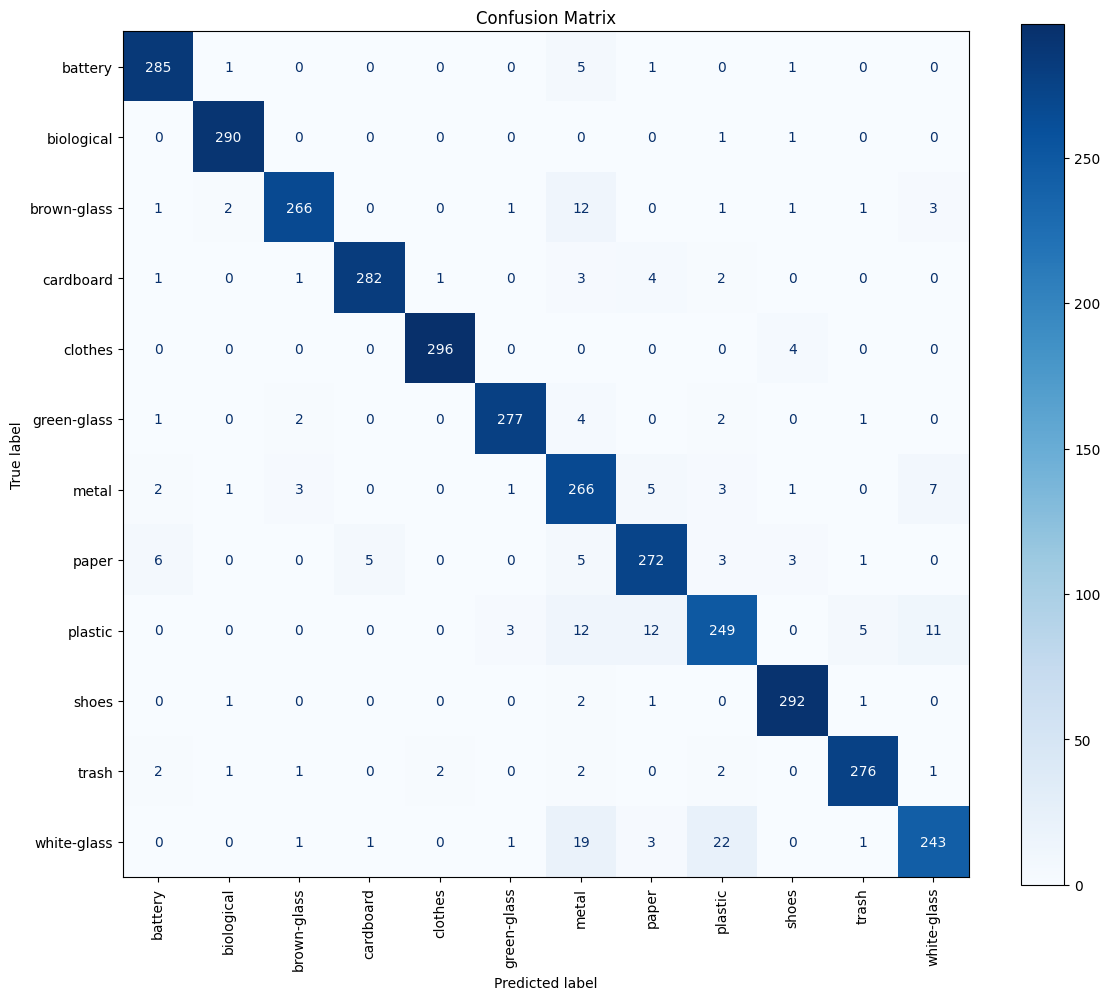

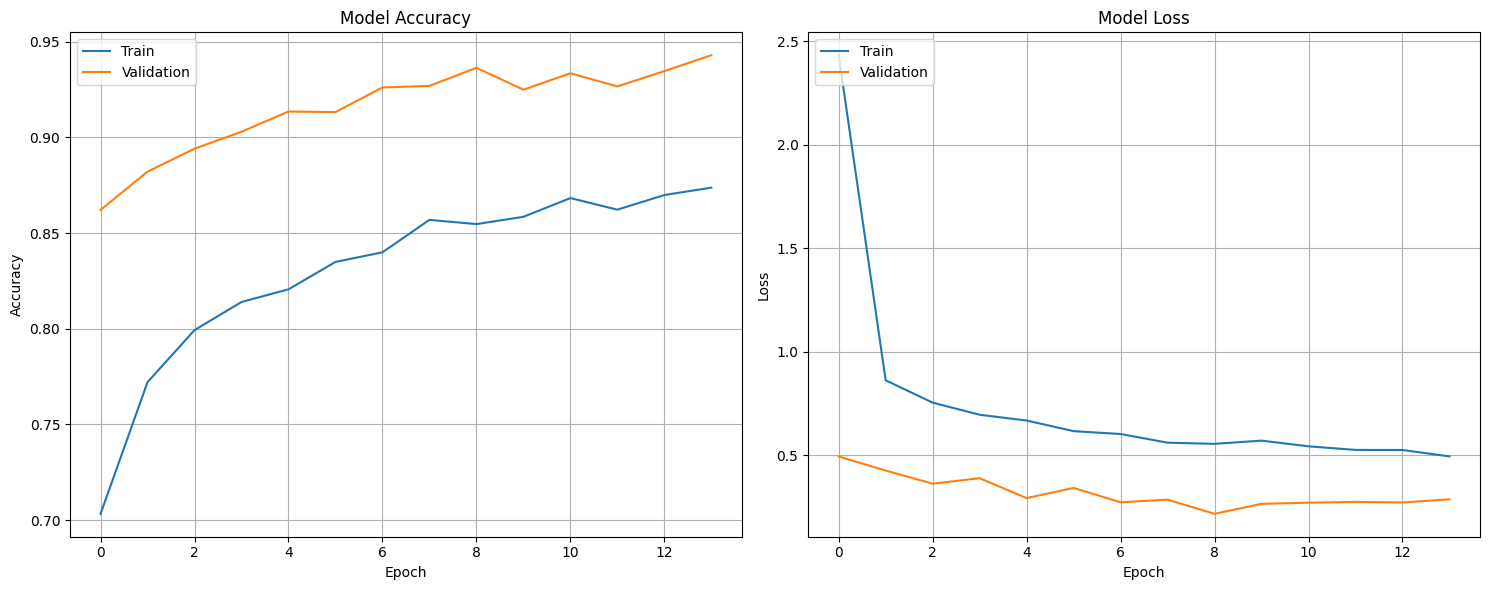

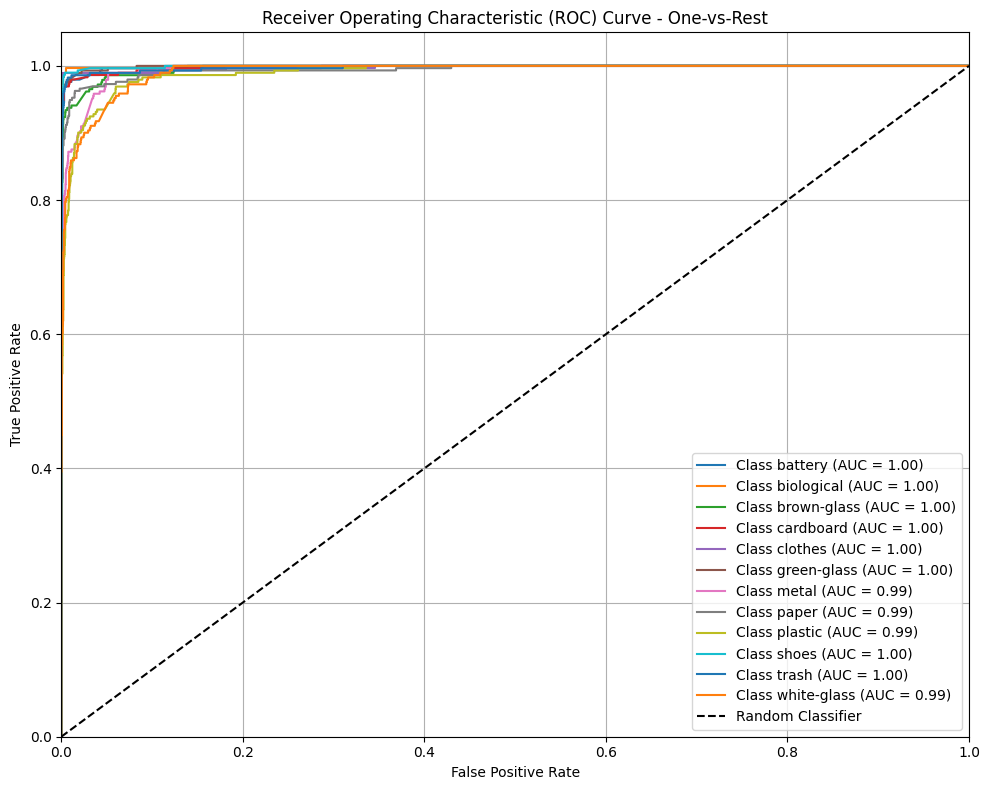

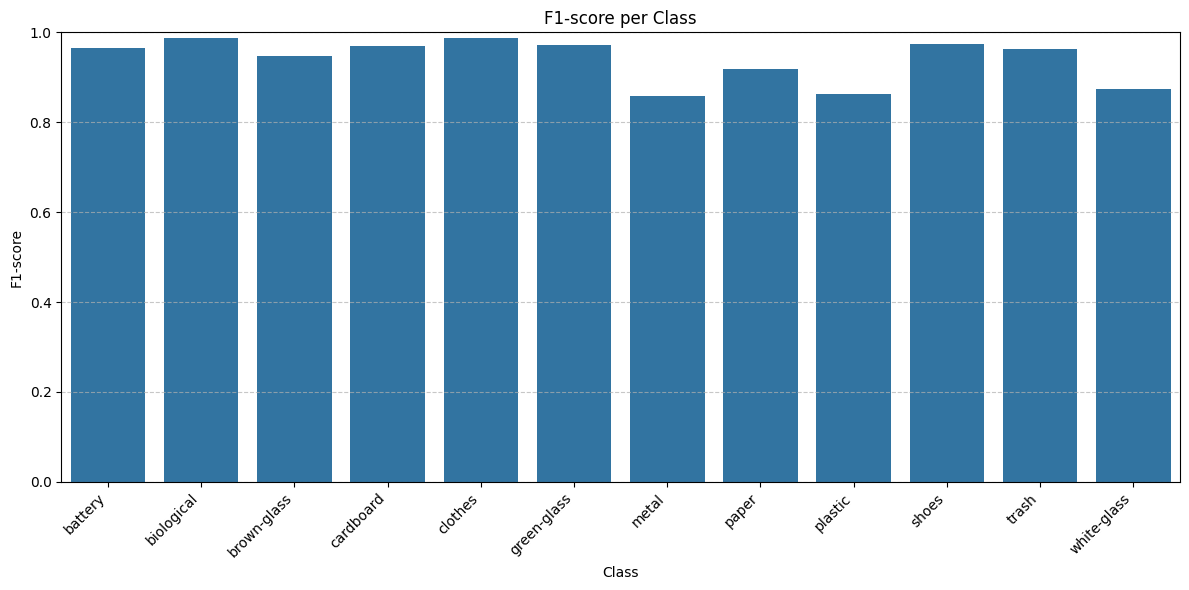

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import os
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, f1_score
from tensorflow.keras.utils import to_categorical # For one-hot encoding

# --- Tạo thư mục để lưu biểu đồ ---
plots_dir = 'evaluation_plots'
os.makedirs(plots_dir, exist_ok=True)
print(f"Biểu đồ sẽ được lưu vào thư mục: {plots_dir}")

# --- Đánh giá mô hình trên tập kiểm tra ---
print("Đánh giá mô hình trên tập kiểm tra...")
loss, accuracy = model.evaluate(test_generator, verbose=0) # verbose=0 để không in thanh tiến trình
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Dự đoán trên tập kiểm tra
# `test_generator.reset()` đảm bảo thứ tự ảnh là như nhau mỗi lần chạy
test_generator.reset()
y_pred_probs = model.predict(test_generator, verbose=0) # verbose=0 để không in thanh tiến trình
y_pred = np.argmax(y_pred_probs, axis=1)

# Lấy nhãn thực tế
y_true = test_generator.classes

# Lấy tên lớp
class_names = list(test_generator.class_indices.keys())

# --- Báo cáo phân loại (Classification Report) ---
print("\nBáo cáo phân loại:")
print(classification_report(y_true, y_pred, target_names=class_names))

# --- 1. Biểu đồ Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig_cm, ax_cm = plt.subplots(figsize=(12, 10))
disp.plot(cmap=plt.cm.Blues, ax=ax_cm, xticks_rotation='vertical')
ax_cm.set_title('Confusion Matrix')
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'confusion_matrix.png'))
plt.show()

# --- 2. Biểu đồ Loss và Accuracy trong quá trình huấn luyện ---
fig_hist, axes_hist = plt.subplots(1, 2, figsize=(15, 6))

# Biểu đồ Accuracy
axes_hist[0].plot(history.history['accuracy'])
axes_hist[0].plot(history.history['val_accuracy'])
axes_hist[0].set_title('Model Accuracy')
axes_hist[0].set_ylabel('Accuracy')
axes_hist[0].set_xlabel('Epoch')
axes_hist[0].legend(['Train', 'Validation'], loc='upper left')
axes_hist[0].grid(True)

# Biểu đồ Loss
axes_hist[1].plot(history.history['loss'])
axes_hist[1].plot(history.history['val_loss'])
axes_hist[1].set_title('Model Loss')
axes_hist[1].set_ylabel('Loss')
axes_hist[1].set_xlabel('Epoch')
axes_hist[1].legend(['Train', 'Validation'], loc='upper left')
axes_hist[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'training_history.png'))
plt.show()


# --- 3. Biểu đồ AUC-ROC (One-vs-Rest cho đa lớp) ---
# Chuyển đổi nhãn thực tế sang định dạng one-hot encoding
y_true_one_hot = to_categorical(y_true, num_classes=len(class_names))

plt.figure(figsize=(10, 8))
for i in range(len(class_names)):
    fpr, tpr, _ = roc_curve(y_true_one_hot[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - One-vs-Rest')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'roc_curve.png'))
plt.show()

# --- 4. Biểu đồ F1-score cho từng lớp ---
f1_scores = f1_score(y_true, y_pred, average=None) # F1 score cho từng lớp
plt.figure(figsize=(12, 6))
sns.barplot(x=class_names, y=f1_scores)
plt.title('F1-score per Class')
plt.xlabel('Class')
plt.ylabel('F1-score')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'f1_score_per_class.png'))
plt.show()

## 7. Dự đoán trên ảnh ngẫu nhiên từ tập kiểm tra

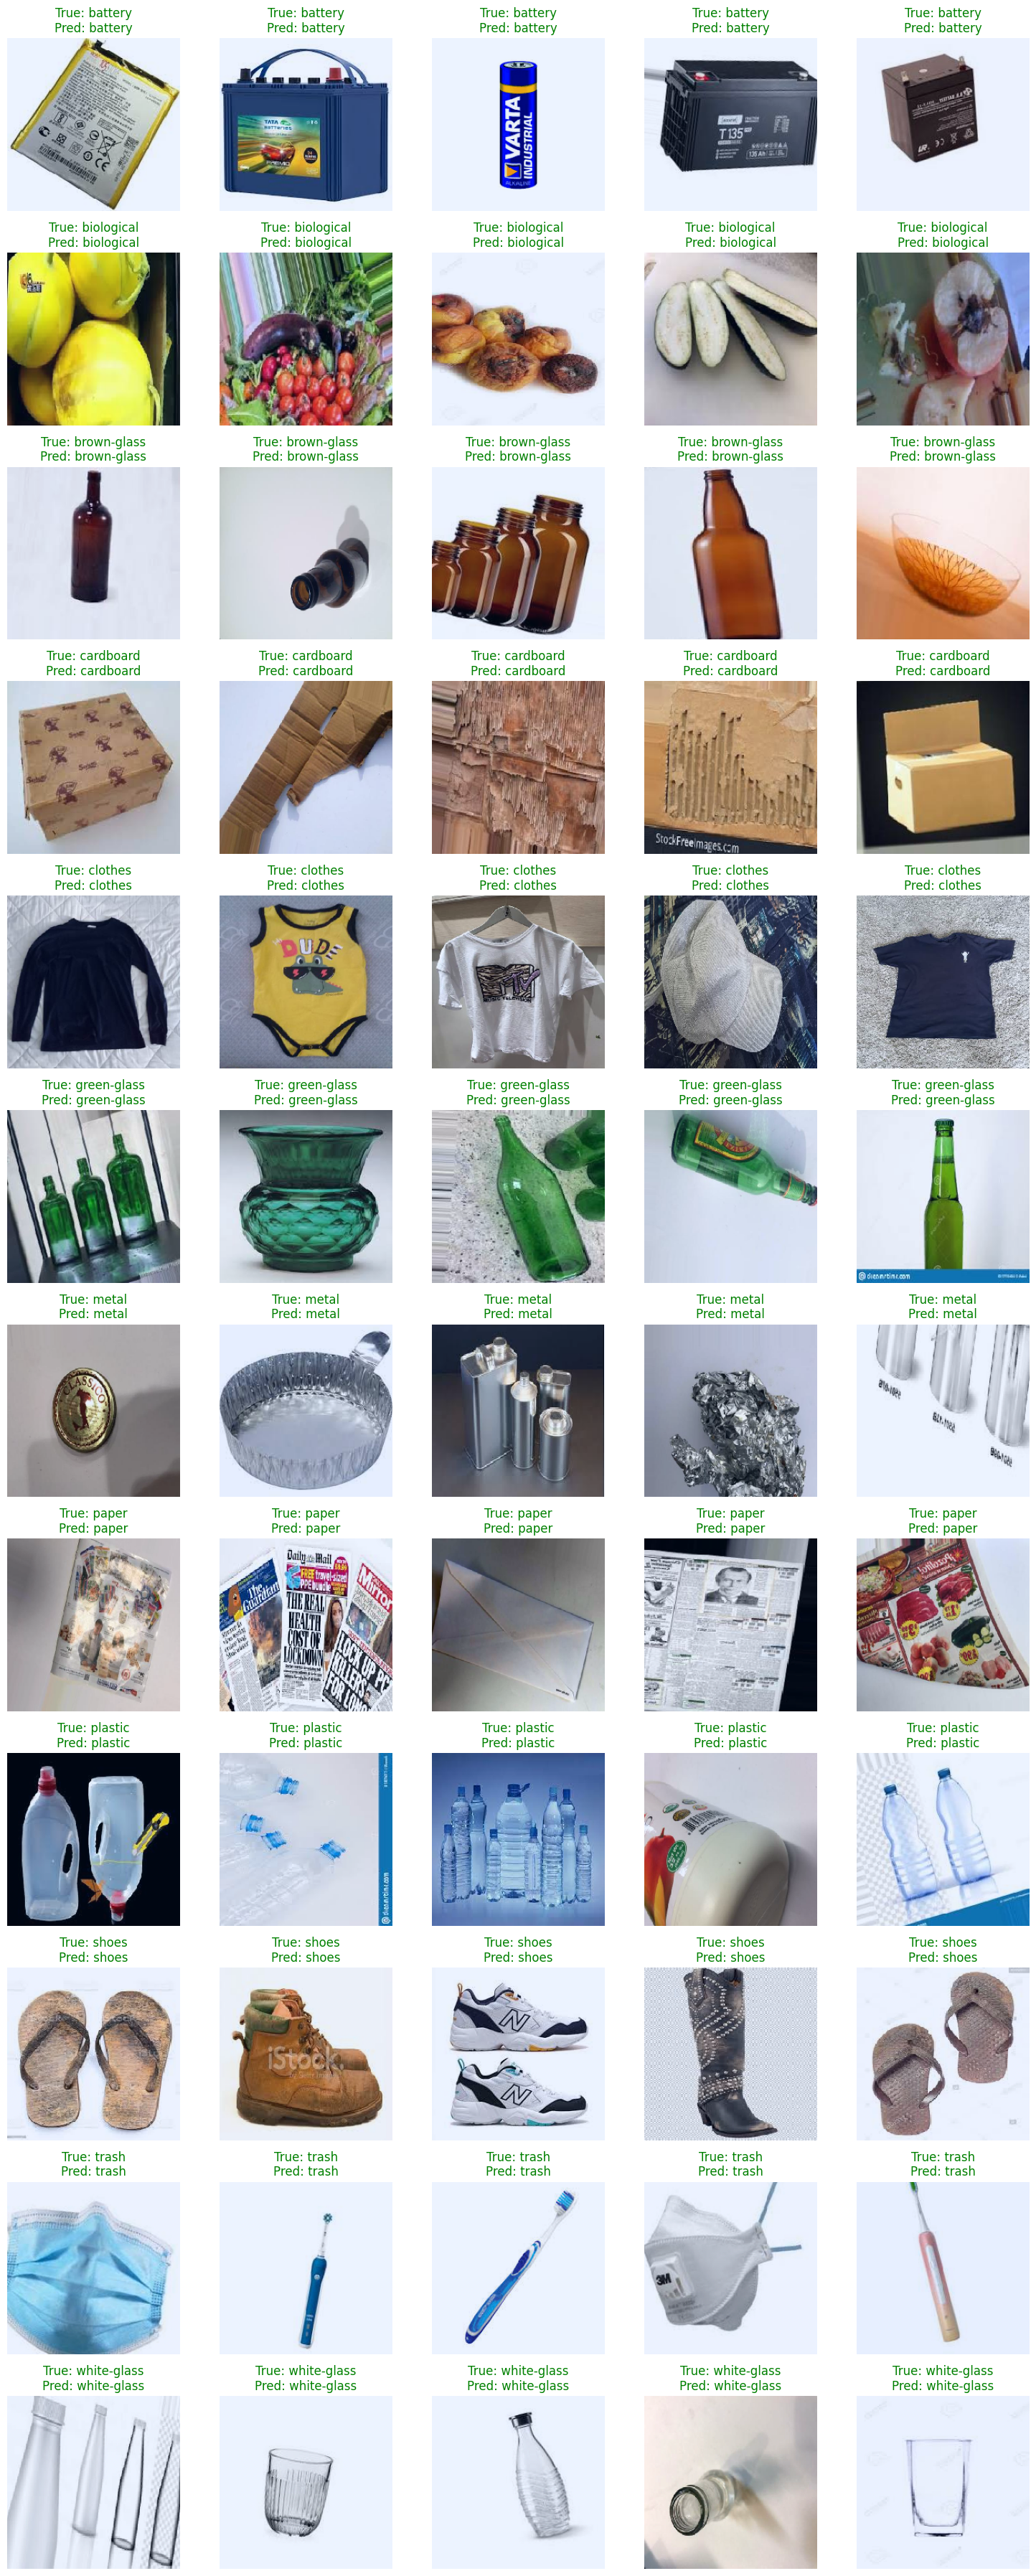

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.resnet import preprocess_input as resnet_preprocess_input
import os
import random

# Hàm để hiển thị ảnh với dự đoán
def display_image_prediction(image_array, true_label, predicted_label, class_names):
    plt.imshow(image_array)
    color = "green" if true_label == predicted_label else "red"
    title = f"True: {class_names[true_label]}\nPred: {class_names[predicted_label]}"
    plt.title(title, color=color)
    plt.axis('off')

# Lấy ánh xạ tên lớp và chỉ mục
class_names = list(test_generator.class_indices.keys())
class_indices = test_generator.class_indices

num_samples_per_class = 5 # Số ảnh muốn hiển thị cho mỗi lớp

plt.figure(figsize=(num_samples_per_class * 3, len(class_names) * 3))

plot_index = 1
for class_name in class_names:
    true_label_idx = class_indices[class_name]
    class_dir = os.path.join(TEST_DIR, class_name)

    # Lấy danh sách tất cả các ảnh trong thư mục của lớp hiện tại
    all_images_in_class = [f for f in os.listdir(class_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]

    # Chọn ngẫu nhiên số ảnh yêu cầu (hoặc tất cả nếu ít hơn)
    selected_images = random.sample(all_images_in_class, min(num_samples_per_class, len(all_images_in_class)))

    for img_file in selected_images:
        img_path = os.path.join(class_dir, img_file)

        # Tải và tiền xử lý ảnh
        img = load_img(img_path, target_size=(IMG_WIDTH, IMG_HEIGHT))
        img_array = img_to_array(img)
        img_array_processed = resnet_preprocess_input(np.expand_dims(img_array, axis=0)) # Thêm chiều batch và tiền xử lý ResNet

        # Dự đoán
        predicted_probs = model.predict(img_array_processed, verbose=0)[0]
        predicted_label_idx = np.argmax(predicted_probs)

        # Chuẩn bị ảnh để hiển thị (đảo ngược tiền xử lý một cách tương đối để hiển thị)
        # resnet_preprocess_input chuyển đổi ảnh từ [0,255] sang khoảng ImageNet.
        # Để hiển thị, ta cần đưa về [0,255]. Cách đơn giản là chuẩn hóa lại.
        image_for_display = img_array # Sử dụng ảnh gốc chưa qua resnet_preprocess_input nhưng đã qua img_to_array
        image_for_display = image_for_display - image_for_display.min()
        image_for_display = image_for_display / image_for_display.max() # Normalize to [0, 1]
        image_for_display = (image_for_display * 255).astype(np.uint8)

        plt.subplot(len(class_names), num_samples_per_class, plot_index)
        display_image_prediction(image_for_display, true_label_idx, predicted_label_idx, class_names)
        plot_index += 1

plt.tight_layout()
plt.show()

In [16]:
import shutil
from google.colab import files

# Nén thư mục evaluation_plots thành file evaluation_plots.zip
shutil.make_archive('/content/evaluation_plots', 'zip', '/content/evaluation_plots')

# Tải file zip đó về máy tính
files.download('/content/evaluation_plots.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>